# 1. LIBRERIAS Y FUNCIONES

In [1]:
# Cargamos Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# modelos lineales
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

# indicadores de ajuste del modelo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,mean_squared_error,r2_score,confusion_matrix,recall_score,classification_report,precision_score,f1_score
from sklearn.metrics import roc_curve, roc_auc_score

# modelos de árboles de decisión
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import GridSearchCV

# ÁRBOLES DE DECISIÓN - CLASIFICACIÓN

**Idea y Objetivo**
Idea principal: dividir el espacio de datos en regiones homogéneas mediante reglas tipo “si-entonces”.

Objetivo: clasificar observaciones en categorías (ej. “aprobado” vs “reprobado”, “fraudulento” vs “legítimo”).

**Principales Elementos**

Nodo raíz: punto inicial donde se evalúa la primera condición.

Nodos de decisión: preguntas intermedias que dividen los datos.

Ramas: caminos que siguen las respuestas.

Hojas: resultados finales (clases asignadas).

✅ **Ventajas**

Fácil de interpretar y explicar.

No requiere supuestos de linealidad.

Maneja variables categóricas y numéricas.

Puede capturar interacciones complejas.

❌ **Desventajas**

Propenso al sobreajuste si no se controla.

Menor precisión comparado con modelos más avanzados (ej. Random Forest, XGBoost).

Inestable: pequeños cambios en datos pueden alterar la estructura.

# 3. DATOS

In [2]:
# cargamos datos

health_df = pd.read_csv('evaluacionh2/healthcare_dataset.csv',sep=',', encoding='iso-8859-1')

print(health_df.shape) #
health_df.head(2)

(55500, 15)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive


In [3]:
health_df['Medical Condition'].value_counts()

Medical Condition
Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Asthma          9185
Name: count, dtype: int64

In [4]:
health_df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='str')

In [5]:
# una copia a los datos
df = health_df.copy()

In [6]:
# convertir a dummies las variables categoricas o cualitativas
df = pd.get_dummies(df, columns=['Medical Condition','Admission Type'], drop_first=True)
print(df.shape)
df.head(2)

(55500, 20)


,Name,Age,Gender,Blood Type,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Discharge Date,Medication,Test Results,Medical Condition_Asthma,Medical Condition_Cancer,Medical Condition_Diabetes,Medical Condition_Hypertension,Medical Condition_Obesity,Admission Type_Emergency,Admission Type_Urgent
0,Bobby JacksOn,30,Male,B-,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,2024-02-02,Paracetamol,Normal,False,True,False,False,False,False,True
1,LesLie TErRy,62,Male,A+,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,2019-08-26,Ibuprofen,Inconclusive,False,False,False,False,True,True,False


In [7]:
## convertir las variables booleanas a enteros
#df = df.replace({True: 1, False: 0})
#df.head(2)

# Convertimos a entero todos los campos que empiezan con 'Education' o 'Marital_Status'
for col in df.columns:
    if col.startswith('Medical Condition') or col.startswith('Admission Type'):
        if df[col].dtype == bool:
            df[col] = df[col].astype(int)
df[[c for c in df.columns if c.startswith('Medical Condition') or c.startswith('Admission Type')]].head(2)

print(df.shape)
df.head(2)

(55500, 20)


,Name,Age,Gender,Blood Type,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Discharge Date,Medication,Test Results,Medical Condition_Asthma,Medical Condition_Cancer,Medical Condition_Diabetes,Medical Condition_Hypertension,Medical Condition_Obesity,Admission Type_Emergency,Admission Type_Urgent
0,Bobby JacksOn,30,Male,B-,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,2024-02-02,Paracetamol,Normal,0,1,0,0,0,0,1
1,LesLie TErRy,62,Male,A+,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,2019-08-26,Ibuprofen,Inconclusive,0,0,0,0,1,1,0


In [9]:
# Aqui hay todo un proceso de exploración y limpieza de datos
# que no se muestra en este notebook

In [8]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Date of Admission', 'Doctor',
       'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number',
       'Discharge Date', 'Medication', 'Test Results',
       'Medical Condition_Asthma', 'Medical Condition_Cancer',
       'Medical Condition_Diabetes', 'Medical Condition_Hypertension',
       'Medical Condition_Obesity', 'Admission Type_Emergency',
       'Admission Type_Urgent'],
      dtype='str')

In [11]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# 1. Cargar el dataset
df = pd.read_csv('evaluacionh2/healthcare_dataset.csv')

# 2. Definir variables para CLASIFICACIÓN
# X: Características (Edad, Género, Tipo de Sangre)
# y: La categoría que queremos adivinar (Medical Condition)
columnas_x = ['Age', 'Gender', 'Blood Type', 'Insurance Provider']
X = pd.get_dummies(df[columnas_x], drop_first=True)
y = df['Medical Condition']

# 3. Dividir los datos
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Crear el modelo de Clasificación (como en tu captura)
# Usamos 'entropy' o 'gini' para medir la pureza de los nodos
modelo_Clasif = DecisionTreeClassifier(
    criterion='entropy', 
    max_depth=3, 
    min_samples_split=5
)

# 5. Entrenar
modelo_Clasif.fit(x_train, y_train)

print(f"Enfermedades a clasificar: {y.unique()}")

Enfermedades a clasificar: <StringArray>
['Cancer', 'Obesity', 'Diabetes', 'Asthma', 'Hypertension', 'Arthritis']
Length: 6, dtype: str


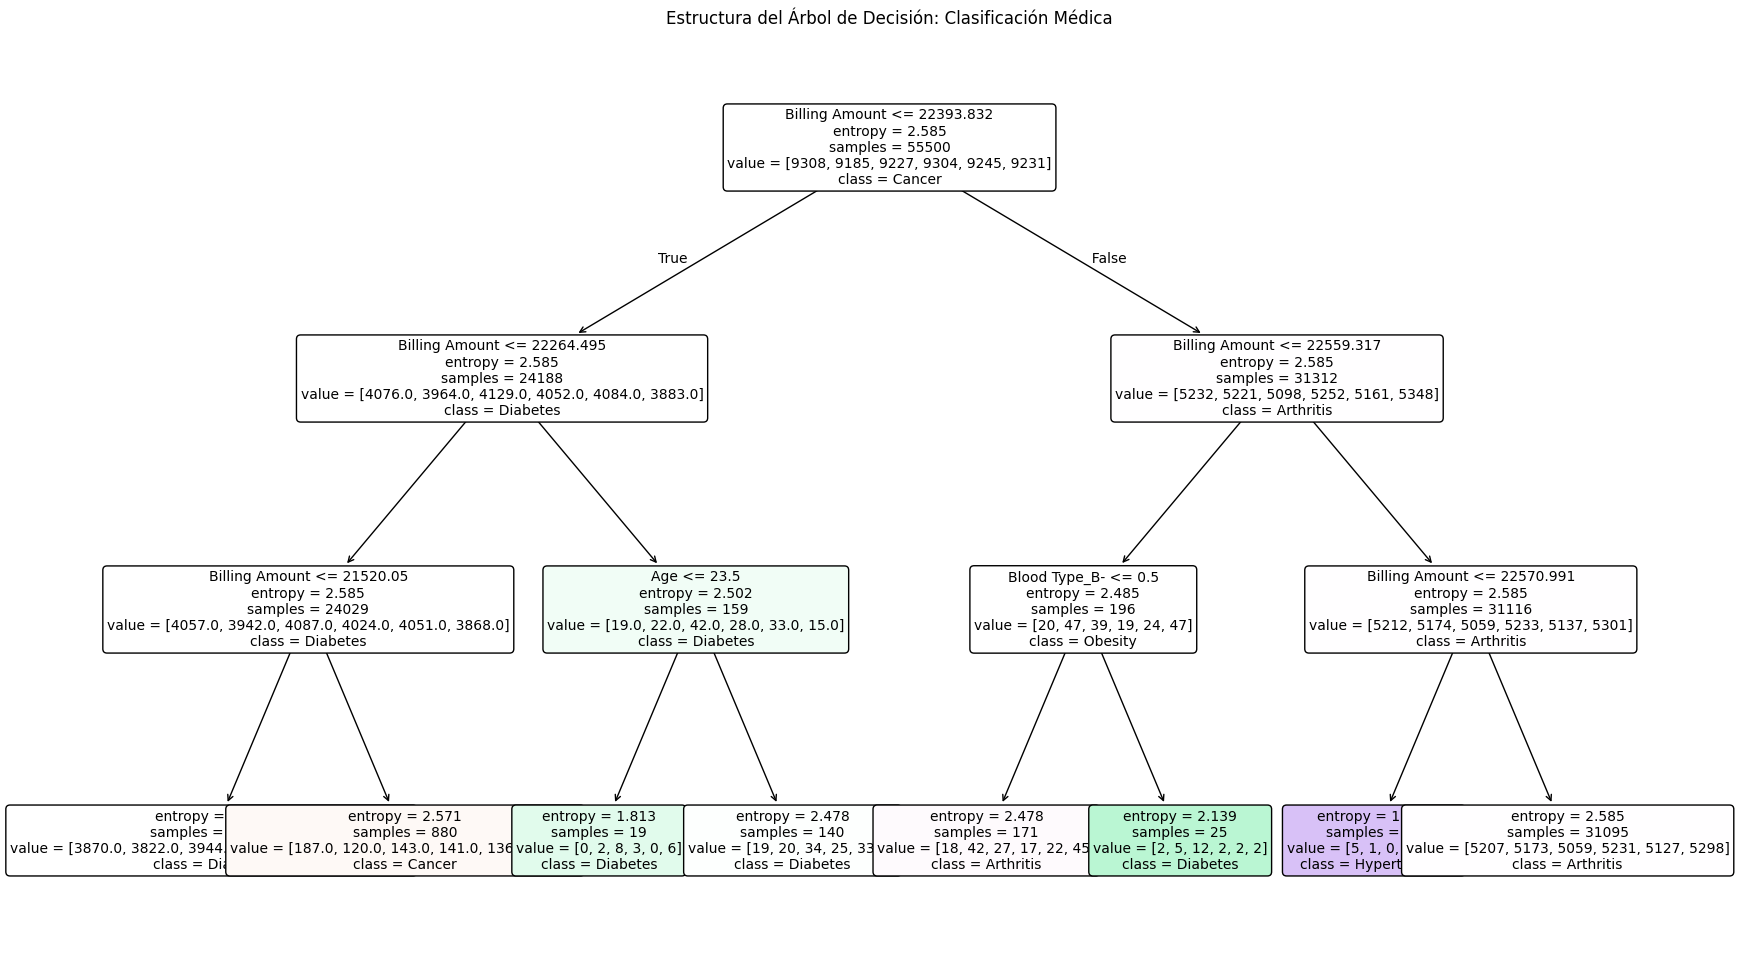

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

# 1. Preparación de datos
df = pd.read_csv('evaluacionh2/healthcare_dataset.csv')
columnas_x = ['Age', 'Billing Amount', 'Gender', 'Blood Type']
X = pd.get_dummies(df[columnas_x], drop_first=True)
y = df['Medical Condition']

# 2. Entrenar el modelo de Clasificación
# Usamos max_depth=3 para que el gráfico sea legible como en tu imagen
modelo_Clasif = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
modelo_Clasif.fit(X, y)

# 3. GENERAR EL GRÁFICO DEL ÁRBOL
plt.figure(figsize=(20, 12))
plot_tree(
    modelo_Clasif, 
    feature_names=X.columns.tolist(), 
    class_names=y.unique().tolist(), 
    filled=True, 
    rounded=True,
    fontsize=10
)

plt.title("Estructura del Árbol de Decisión: Clasificación Médica")
plt.show()

In [14]:
y.head(2)

0     Cancer
1    Obesity
Name: Medical Condition, dtype: str

In [15]:
# Dividir los datos en conjuntos de entrenamiento y prueba o testeo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=777)

In [17]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Cargar y preparar datos
df = pd.read_csv('evaluacionh2/healthcare_dataset.csv')
X = pd.get_dummies(df[['Age', 'Billing Amount', 'Gender', 'Blood Type']], drop_first=True)
y = df['Medical Condition']

# Dividir para tener datos de prueba que el modelo no conoce
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Entrenar el modelo
modelo_Clasif = DecisionTreeClassifier(criterion='entropy', max_depth=3)
modelo_Clasif.fit(x_train, y_train)

# 3. PREDICCIÓN (Lo que muestra tu imagen)
y_pred = modelo_Clasif.predict(x_test)

# Crear la tabla comparativa (Primeros 10 resultados)
df_comparacion = pd.DataFrame({'Valor Real': y_test, 'Predicción': y_pred})
print("--- Comparativa de Clasificación ---")
print(df_comparacion.head(10))

# 4. CÁLCULO DE PRECISIÓN
precision = accuracy_score(y_test, y_pred)
print(f"\nExactitud del Modelo (Accuracy): {precision:.2%}")

--- Comparativa de Clasificación ---
      Valor Real Predicción
31641   Diabetes     Cancer
9246    Diabetes    Obesity
1583      Asthma    Obesity
36506    Obesity    Obesity
11259    Obesity    Obesity
8972      Cancer     Cancer
36078     Asthma    Obesity
42659   Diabetes    Obesity
6545   Arthritis     Cancer
35448     Cancer    Obesity

Exactitud del Modelo (Accuracy): 16.82%


In [18]:
# Entrenamos el Modelo de Árbol de Decisión para Clasificación

# Crea un clasificador de árbol de decisión
modelo_ArbolDecisionClasif = DecisionTreeClassifier(max_depth=1,min_samples_leaf=1,min_samples_split=2)

# Entrena el modelo en los datos de entrenamiento
modelo_ArbolDecisionClasif.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

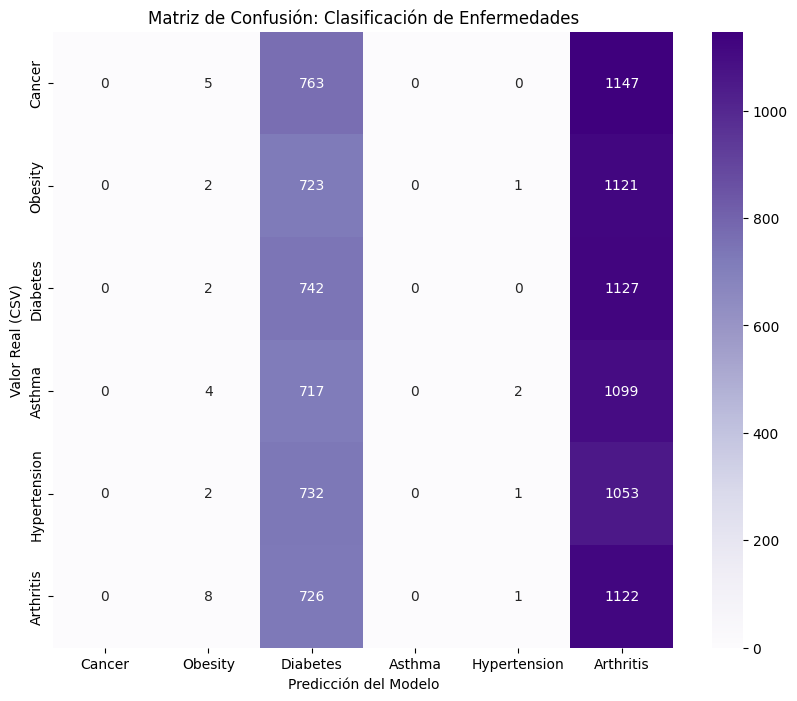

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# 1. Preparación de datos
df = pd.read_csv('evaluacionh2/healthcare_dataset.csv')
X = pd.get_dummies(df[['Age', 'Billing Amount', 'Gender', 'Blood Type']], drop_first=True)
y = df['Medical Condition']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Entrenar el modelo de Clasificación
modelo_Clasif = DecisionTreeClassifier(criterion='entropy', max_depth=3)
modelo_Clasif.fit(x_train, y_train)

# 3. Predicciones
y_pred = modelo_Clasif.predict(x_test)

# 4. GENERAR LA MATRIZ DE CONFUSIÓN (Como en tu imagen)
cm = confusion_matrix(y_test, y_pred)
etiquetas = y.unique()

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=etiquetas, yticklabels=etiquetas)

plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real (CSV)')
plt.title('Matriz de Confusión: Clasificación de Enfermedades')
plt.show()

In [13]:
y_train.value_counts()

Response
0    1526
1     266
Name: count, dtype: int64

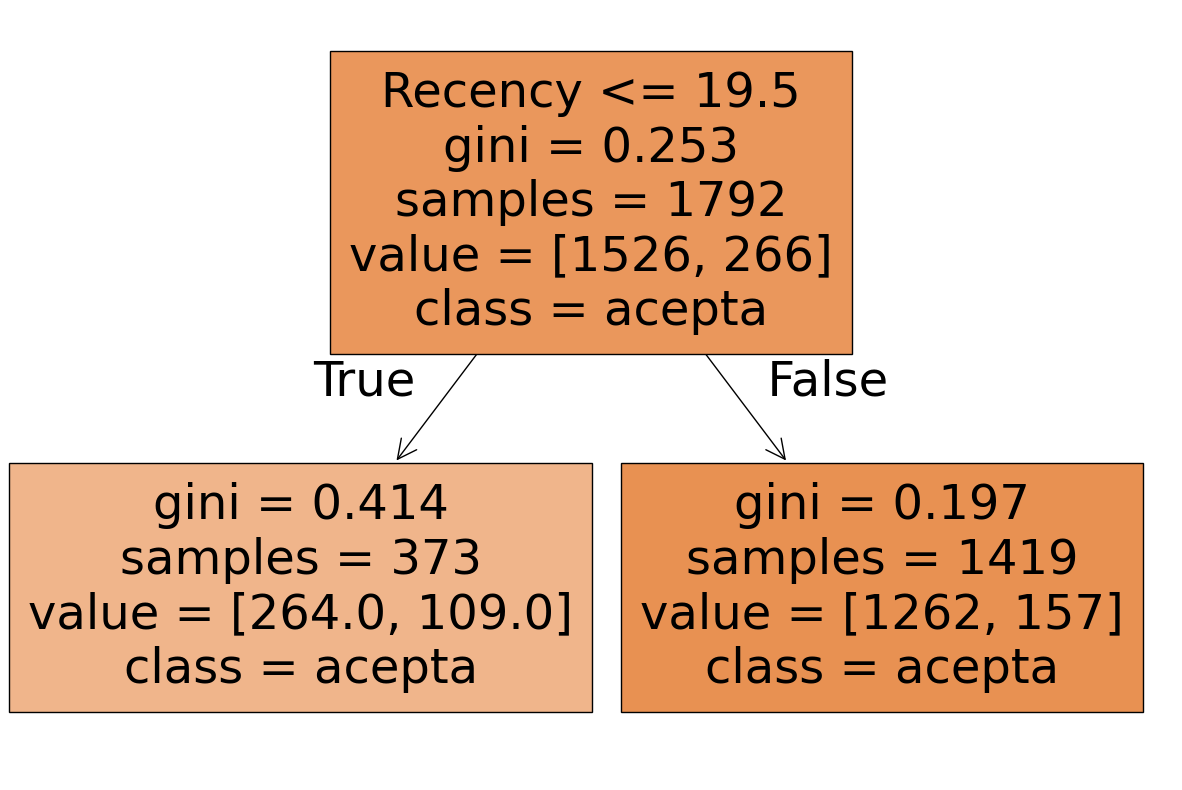

In [46]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))
plot_tree(modelo_ArbolDecisionClasif, filled=True, feature_names=X_train.columns, class_names=['acepta', 'no acepta'])
plt.show()

In [14]:
# poner una semilla para reproducibilidad del modelo
np.random.seed(42)

In [15]:
X_train.head(2)

,Kidhome,Recency
351,1,93
1640,1,56


In [21]:
y_train.dtypes

dtype('int64')

In [22]:
# Ajusta el modelo de regresión logística
modelo_logit = sm.Logit(y_train, X_train).fit()

Optimization terminated successfully.
         Current function value: 0.404446
         Iterations 6


In [23]:
# Muestra un resumen del modelo
print(modelo_logit.summary())

                           Logit Regression Results                           
Dep. Variable:               Response   No. Observations:                 1792
Model:                          Logit   Df Residuals:                     1790
Method:                           MLE   Df Model:                            1
Date:                Thu, 09 Apr 2026   Pseudo R-squ.:                 0.03701
Time:                        14:52:45   Log-Likelihood:                -724.77
converged:                       True   LL-Null:                       -752.62
Covariance Type:            nonrobust   LLR p-value:                 8.410e-14
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Kidhome       -0.7973      0.125     -6.388      0.000      -1.042      -0.553
Recency       -0.0309      0.002    -18.138      0.000      -0.034      -0.028


In [24]:
X_test

,Kidhome,Recency
0,1,10
1,1,33
2,0,6
3,0,40
4,0,3
...,...,...
443,1,49
444,0,3
445,0,64
446,1,39


In [19]:
# ajustamos el indice en x_test
X_test.reset_index(drop=True, inplace=True)


In [18]:
X_test

,Kidhome,Recency
585,1,10
549,1,33
619,0,6
77,0,40
1875,0,3
...,...,...
147,1,49
40,0,3
1228,0,64
1988,1,39


In [25]:
# Realiza predicciones en el conjunto de datos de prueba

# Regresión Logistica - Logit
print('Predicción Regresión Logística - Logit')
y_pred_logit = modelo_logit.predict(X_test)
print(y_pred_logit.head(2))

# Arbol de Decisión - Clasificación
print('Predicción Árbol de Decisión - Clasificación')
y_pred_ArbolDecisionClasif = modelo_ArbolDecisionClasif.predict_proba(X_test)
y_pred_ArbolDecisionClasif = pd.DataFrame(y_pred_ArbolDecisionClasif)
y_pred_ArbolDecisionClasif = y_pred_ArbolDecisionClasif.iloc[:,1]
print(y_pred_ArbolDecisionClasif.head(2))

Predicción Regresión Logística - Logit
0    0.248624
1    0.139929
dtype: float64
Predicción Árbol de Decisión - Clasificación
0    0.292225
1    0.110641
Name: 1, dtype: float64


In [26]:
# Obteniendo el mejor corte de predicción
# Calcular la curva ROC - LOGIT
fpr, tpr, thresholds = roc_curve(y_test, y_pred_logit)

# Encontrar el umbral óptimo (máximo índice de Youden)
youden_index = tpr - fpr
optimal_threshold_logit = thresholds[np.argmax(youden_index)]

print("Umbral óptimo Logit:", optimal_threshold_logit)

Umbral óptimo Logit: 0.1760580534614822


In [27]:
# Obteniendo el mejor corte de predicción
# Calcular la curva ROC - Arbol de Decisión
fpr, tpr, thresholds = roc_curve(y_test, y_pred_ArbolDecisionClasif)

# Encontrar el umbral óptimo (máximo índice de Youden)
youden_index = tpr - fpr
optimal_threshold_tree = thresholds[np.argmax(youden_index)]

print("Umbral óptimo- Arbol de Decisión:", optimal_threshold_tree)

Umbral óptimo- Arbol de Decisión: 0.29222520107238603


In [28]:
y_pred_ArbolDecisionClasif

0      0.292225
1      0.110641
2      0.292225
3      0.110641
4      0.292225
         ...   
443    0.110641
444    0.292225
445    0.110641
446    0.110641
447    0.110641
Name: 1, Length: 448, dtype: float64

In [29]:
(y_pred_logit>=optimal_threshold_logit).astype(int)

0      1
1      0
2      1
3      1
4      1
      ..
443    0
444    1
445    0
446    0
447    0
Length: 448, dtype: int64

In [30]:
# Matriz de confusión

            #Predicción
            #   0   1
#Valor Real 0 # VN FP
#Valor Real 1 # FN VP

# Regresión Logistica - Logit
confusion = confusion_matrix(y_test, (y_pred_logit>=optimal_threshold_logit).astype(int))
print("Matriz de confusión - Logit:")
print(confusion)

# Árbol de Decisión - Clasificación
confusion = confusion_matrix(y_test, (y_pred_ArbolDecisionClasif>=optimal_threshold_tree).astype(int))
print("\nMatriz de confusión - Árbol de Decisión:")
print(confusion)

Matriz de confusión - Logit:
[[260 120]
 [ 25  43]]

Matriz de confusión - Árbol de Decisión:
[[320  60]
 [ 45  23]]


In [31]:
# Exactitud o Accuracy del modelo

# Regresión Logistica - Logit
exactitud_test_logit = accuracy_score(y_test, (y_pred_logit>=optimal_threshold_logit).astype(int))
print("Precisión del modelo-Logit:", exactitud_test_logit)

# Árbol de Decisión - Clasificación
exactitud_test_ArbolDecisionClasif = accuracy_score(y_test, (y_pred_ArbolDecisionClasif>=optimal_threshold_tree).astype(int))
print("Precisión del modelo-Arbol de Decisión:", exactitud_test_ArbolDecisionClasif)

Precisión del modelo-Logit: 0.6763392857142857
Precisión del modelo-Arbol de Decisión: 0.765625


In [ ]:
## para exactitud LOGIT
#(157+70)/(157+205+9+70)
#
## para exactitud Árbol de Decisión
#(280+35)/(280+82+44+35)

0.7142857142857143

In [83]:
# Sensibilidad (Proporción de verdaderos positivos de los valores reales positivos)

# Regresion Logistica - Logit
sensibilidad_test_logit = recall_score(y_test, (y_pred_logit>=optimal_threshold_logit).astype(int))
print("Sensibilidad del modelo-Logit:", sensibilidad_test_logit)

# Árbol de Decisión - Clasificación
sensibilidad_test_ArbolDecisionClasif = recall_score(y_test, (y_pred_ArbolDecisionClasif>=optimal_threshold_tree).astype(int))
print("Sensibilidad del modelo-Arbol de Decisión:", sensibilidad_test_ArbolDecisionClasif)

Sensibilidad del modelo-Logit: 0.6176470588235294
Sensibilidad del modelo-Arbol de Decisión: 0.3382352941176471


In [ ]:
## Sensibilidad Logit
#70/(70+9)
#
## sensibilidad Arbol de Decisión
#35/(35+44)

0.4430379746835443

In [84]:
# Precisión (Proporción de Verdaderos Positivos de las predicciónes positivas del modelo)

# Regresión Logistica - Logit
precision_score_logit = precision_score(y_test, (y_pred_logit>=optimal_threshold_logit).astype(int))
print("Precisión del modelo - Logit", precision_score_logit)

# Arbol de Decisión - Clasificación
precision_score_ArbolDecisionClasif = precision_score(y_test, (y_pred_ArbolDecisionClasif>=optimal_threshold_tree).astype(int))
print("Precisión del modelo - Árbol de Decisión", precision_score_ArbolDecisionClasif)

Precisión del modelo - Logit 0.2625
Precisión del modelo - Árbol de Decisión 0.27710843373493976


In [85]:
# f1 sxore
# Regresión Logistica - Logit
precision_score_logit = f1_score(y_test, (y_pred_logit>=optimal_threshold_logit).astype(int))
print("Precisión del modelo - Logit", precision_score_logit)

# Arbol de Decisión - Clasificación
precision_score_ArbolDecisionClasif = f1_score(y_test, (y_pred_ArbolDecisionClasif>=optimal_threshold_tree).astype(int))
print("Precisión del modelo - Árbol de Decisión", precision_score_ArbolDecisionClasif)

Precisión del modelo - Logit 0.3684210526315789
Precisión del modelo - Árbol de Decisión 0.304635761589404


# 3. RESULTADOS

In [ ]:
print('Nro de clientes en el piloto',df.shape[0])

Nro de clientes en el piloto 2205


In [ ]:
costo_piloto=6720
costo_piloto

6720

In [ ]:
ingreso_piloto=3674
ingreso_piloto

3674

In [ ]:
# beneficio del piloto
ingreso_piloto-costo_piloto

-3046

In [ ]:
# Propuesta

In [ ]:
# calculamos el ingreso por cliente
print('Clientes que aceptaron la oferta',df[df['Response']==1].shape[0],'de',df.shape[0],'clientes')
ingreso_xcliente = ingreso_piloto/df[df['Response']==1].shape[0]
print('ingreso por cliente que aceptó la oferta',ingreso_xcliente)

Clientes que aceptaron la oferta 333 de 2205 clientes
ingreso por cliente que aceptó la oferta 11.033033033033034


In [ ]:
# costo por cliente
costo_xcliente = costo_piloto/df.shape[0]
print('Costo por cliente',costo_xcliente)

Costo por cliente 3.0476190476190474


In [ ]:
# Regresión Logistica - Logit
confusion = confusion_matrix(y_test, (y_pred_logit>=optimal_threshold_logit).astype(int))
print("Matriz de confusión - Logit:")
print(confusion)

# Árbol de Decisión - Clasificación
confusion = confusion_matrix(y_test, (y_pred_ArbolDecisionClasif>=optimal_threshold_tree).astype(int))
print("\nMatriz de confusión - Árbol de Decisión:")
print(confusion)

Matriz de confusión - Logit:
[[260 102]
 [ 34  45]]

Matriz de confusión - Árbol de Decisión:
[[120 242]
 [ 12  67]]


In [ ]:
# inversión o costo - LOGIT, datos de testeo, representan un 20% del total de clientes en piloto
ingreso_xcliente*70-costo_xcliente*(102+45)

324.3123123123123

In [ ]:
# inversion o costo Arbol de Decisión, datos de testeo, representan un 20% del total de clientes en piloto
ingreso_xcliente*35-costo_xcliente*(242+67)

-555.5581295581295

In [ ]:
# beneficio en $us
# 324 es 20% # porcentaje del grupo de testeo
# x es al 100%(piloto) # total en el piloto

In [ ]:
# beneficio en clientes total del piloto
324*1/0.2

1620.0

In [ ]:
# se enviara campaña a solo un
(82+35)/(280+82+44+35)

# en un 26% de clientes con alta probabilidad , puedo tener benficios positivos,
# bajo el supuesto que mi población es 2205 clientes (piloto) , se tendra un beneficio de 145 $us

0.2653061224489796